# quick subsample from gaia pairwise scoring output  


group by run and bin, then downsample evenly across the nodeheight distribution 

## import pkgs

In [12]:
import os
#import itertools
import csv

#import subprocess, gzip, tempfile
#import shutil

#from concurrent.futures import ProcessPoolExecutor, as_completed
import warnings

#from pathlib import Path
#from collections import defaultdict

import traceback

#from tqdm.notebook import tqdm

#import tsinfer
#import tskit
#import msprime
#import tsdate

import numpy as np
import pandas as pd

#import datetime as dt
#import time

#import matplotlib.pyplot as plt
#%matplotlib inline 

# from sklearn.linear_model import LinearRegression
#from itertools import combinations
#import random 

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

## set wd

In [3]:
os.getcwd()

'/home/nahmed/git/bacterial-args/migration/sweep'

## read in files, data prep

In [6]:
df = pd.read_csv("scores_eq_pairs_003.csv")

/loc/scratch/49822803/ipykernel_26767/2498977423.py:1: DtypeWarning: Columns (28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("scores_eq_pairs_003.csv")


In [6]:
df.columns

Index(['Unnamed: 0', 'X', 'sample_a', 'sample_b', 'bin', 'position',
       'mrca_population', 'node_height_sim', 'node', 'node_time', 'node_state',
       'rep1', 'rep2', 'rep3', 'rep4', 'rep5', 'rep6', 'rep7', 'rep8', 'rep9',
       'rep10', 'mode', 'score', 'model', 'pm', 'mu', 'mr', 'seed',
       'gaia_target', 'costfunction'],
      dtype='object')

In [7]:
# if gaia_target = sim, node_height_sim = node_time 
df.loc[df['gaia_target'] == 'sim', 'node_height_sim'] = df['node_time']

## downsample 

In [8]:
# transform node heights onto log scale 
df['node_height_log'] = np.log(df['node_height_sim'])

# choose number of node_height bins to sample from 
bins = 10 # probably should make it more granular? 

# assign node_height bin at the level of individual subtree scores [within-run, within-bin] 
df['nh_bin'] = df.groupby(['seed', 'mu', 'pm', 'mr', 'bin', 'position', 'gaia_target'])['node_height_log'].transform(
    lambda x: pd.cut(x, bins=bins, labels=False))

#sample 3 rows per nh_bin -- i.e. 30 pairwise comparisons per genomic bin. i.e. 900 points per run? there's ~600 runs (1200 including sim + inf) --> ~1 million rows 
downsampled_df = df.groupby(['seed', 'mu', 'pm', 'mr', 'bin', 'position', 'gaia_target', 'nh_bin']).apply(
    lambda x: x.sample(min(len(x), 3))).reset_index(drop=True)

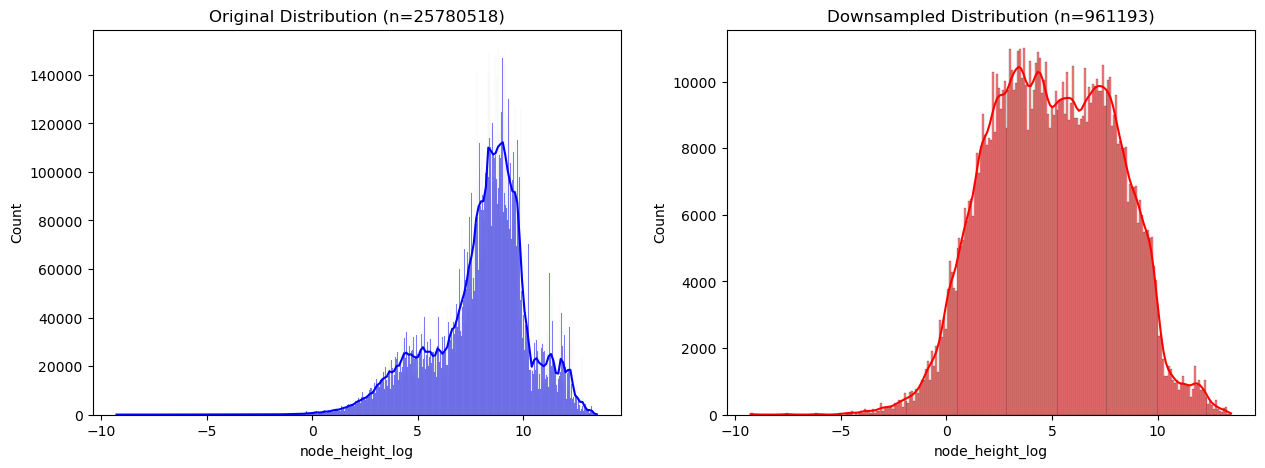

In [22]:
#downsampled_df = pd.read_csv("scores_eq_pairs_003_downsample.csv")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['node_height_log'], kde=True, ax=axes[0], color='blue')
axes[0].set_title(f'Original Distribution (n={len(df)})')

sns.histplot(downsampled_df['node_height_log'], kde=True, ax=axes[1], color='red')
axes[1].set_title(f'Downsampled Distribution (n={len(downsampled_df)})')

plt.show()

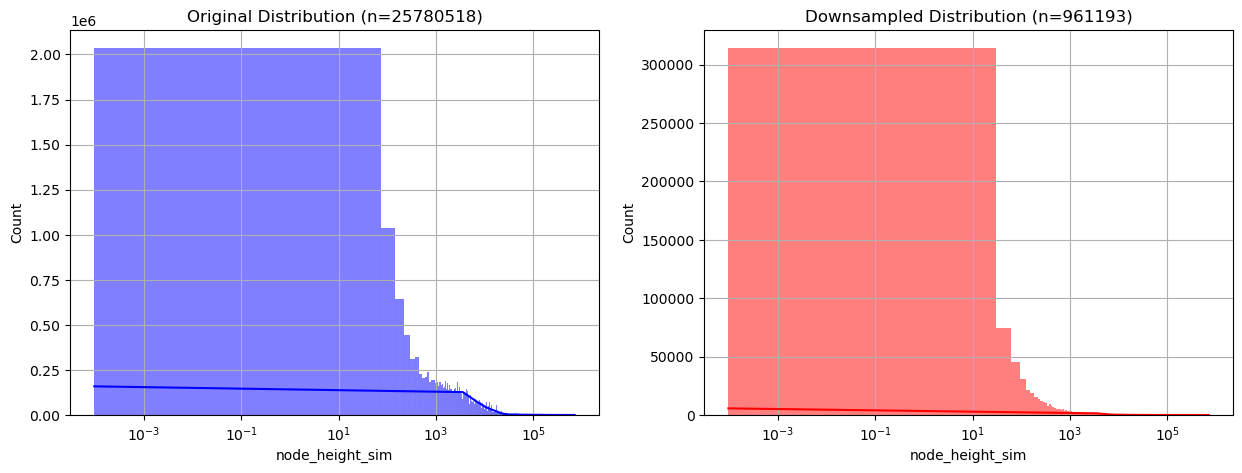

In [23]:
#downsampled_df = pd.read_csv("scores_eq_pairs_003_downsample.csv")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['node_height_sim'], kde=True, ax=axes[0], color='blue')
axes[0].set_title(f'Original Distribution (n={len(df)})')
axes[0].set_xscale('log')
axes[0].grid(True, which="both", ls="-")

sns.histplot(downsampled_df['node_height_sim'], kde=True, ax=axes[1], color='red')
axes[1].set_title(f'Downsampled Distribution (n={len(downsampled_df)})')
axes[1].set_xscale('log')
axes[1].grid(True, which="both", ls="-")

plt.show()

In [9]:
downsampled_df

,Unnamed: 0,X,sample_a,sample_b,bin,position,mrca_population,node_height_sim,node,node_time,...,score,model,pm,mu,mr,seed,gaia_target,costfunction,node_height_log,nh_bin
0,12754359,13026861,15,21,0,50000,2,0.447967,31,0.447967,...,1,ss,0.001,1.000000e-10,0.00001,15,sim,eq,-0.803036,0
1,12754342,13026844,14,19,0,50000,2,1.438205,32,1.438205,...,1,ss,0.001,1.000000e-10,0.00001,15,sim,eq,0.363396,1
2,12754305,13026807,12,15,0,50000,2,8.130842,33,8.130842,...,1,ss,0.001,1.000000e-10,0.00001,15,sim,eq,2.095665,2
3,12754454,13026956,24,26,0,50000,3,10.140114,35,10.140114,...,1,ss,0.001,1.000000e-10,0.00001,15,sim,eq,2.316499,2
4,12754311,13026813,12,21,0,50000,2,8.130842,33,8.130842,...,1,ss,0.001,1.000000e-10,0.00001,15,sim,eq,2.095665,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
961188,21507437,21779939,16,21,29,2950000,1,3086.169385,943,3086.169385,...,1,ss,0.300,1.000000e-07,0.00500,639,sim,eq,8.034686,7
961189,21507329,21779831,7,21,29,2950000,1,1783.397040,680,1783.397040,...,1,ss,0.300,1.000000e-07,0.00500,639,sim,eq,7.486275,7
961190,21507359,21779861,9,20,29,2950000,1,15610.011412,1809,15610.011412,...,1,ss,0.300,1.000000e-07,0.00500,639,sim,eq,9.655668,9
961191,21507298,21779800,6,7,29,2950000,1,15610.011412,1809,15610.011412,...,1,ss,0.300,1.000000e-07,0.00500,639,sim,eq,9.655668,9


In [ ]:
# plot distribution of nh_bin 
plt.hist(downsampled_df['nh_bin'], bins=10, edgecolor='black', color='skyblue')
plt.xlabel('nh_bin')
plt.ylabel('Frequency')
plt.show()

In [ ]:
plt.hist(downsampled_df['node_height_log'], bins=10, edgecolor='black', color='skyblue')
plt.xlabel('log node_height')
plt.ylabel('Frequency')
plt.show()

In [ ]:
plt.hist(downsampled_df['node_height_sim'], bins=10000, edgecolor='black', color='skyblue')
plt.xlabel('node_height')
plt.xscale('log')
plt.ylabel('Frequency')
plt.show()

In [31]:
#downsampled_df = downsampled_df.drop(columns=['nh_bin'])

In [38]:
#downsampled_df.to_csv("scores_eq_pairs_003_downsample.csv")

# plot original distribution vs new distribution 

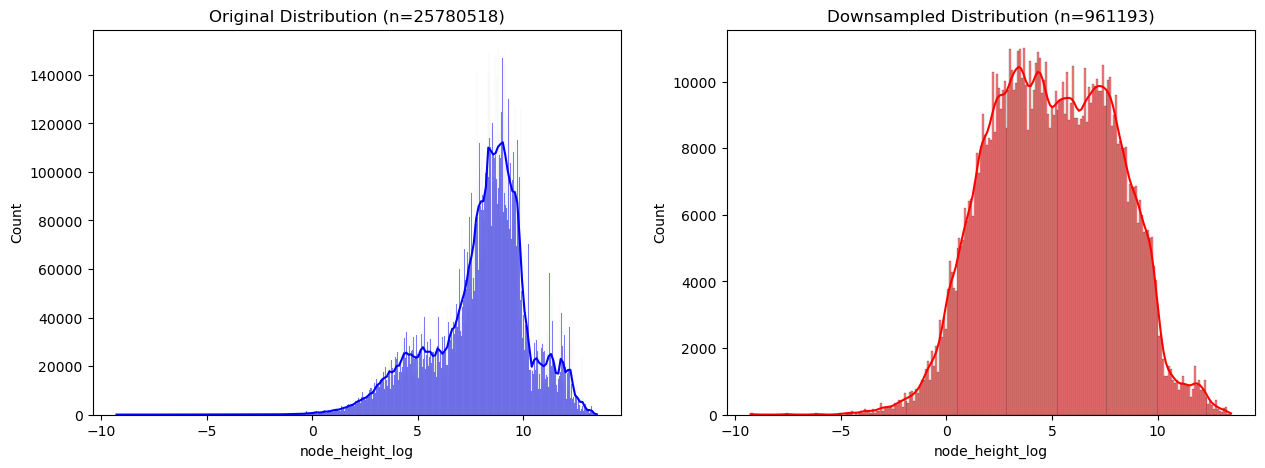

In [22]:
#downsampled_df = pd.read_csv("scores_eq_pairs_003_downsample.csv")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['node_height_log'], kde=True, ax=axes[0], color='blue')
axes[0].set_title(f'Original Distribution (n={len(df)})')

sns.histplot(downsampled_df['node_height_log'], kde=True, ax=axes[1], color='red')
axes[1].set_title(f'Downsampled Distribution (n={len(downsampled_df)})')

plt.show()

### notes

##### need to plot distributions of node heights to determine whether sampling looks good. 

original number rows: 25,780,518

with 20 node_height bins, 10 samples per bin: 3,876,367

with 20 node_height bins, 3 samples per bin: 1,516,243

with 10 node_height bins, 3 samples per bin: 961193